In [46]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from typing import List, Dict

In [47]:
# Global variables to store models and encoders
bulk_model = None
cut_model = None
bulk_encoders = {}
cut_encoders = {}

In [48]:
# Baseline calculation functions (same as bulk.ipynb)
def get_baseline_params(age, gender, experience, current_size_cm, workout_time_years):
    if gender == 'M':
        base_limit = 45
        age_factor = max(0.7, 1 - (age - 25) * 0.01)
    else:
        base_limit = 30
        age_factor = max(0.7, 1 - (age - 25) * 0.008)
    
    M_max = base_limit * age_factor
    remaining_potential = max(0, M_max - (current_size_cm * 0.2))
    
    k_base = {'Beginner': 0.20, 'Intermediate': 0.10, 'Advanced': 0.05}
    k = k_base.get(experience, 0.10) * (1 / (1 + workout_time_years * 0.1))
    
    return remaining_potential, k

def calculate_baseline_growth(row, time_months, current_size_cm, workout_time_years):
    M_max, k = get_baseline_params(row['age'], row['gender'], row['experience'], current_size_cm, workout_time_years)
    M0 = current_size_cm * 0.2
    baseline_growth = (M_max - M0) * (1 - np.exp(-k * time_months))
    baseline_cm2 = baseline_growth * 5
    return max(baseline_cm2, 0.1)  # Ensure minimum baseline to avoid division by zero

In [49]:
# Definition calculation functions
def calculate_baseline_definition(body_fat_percentage, muscle_size_cm2, cardio_minutes_per_week, caloric_deficit):
    """Calculate baseline definition score (1-5 scale)"""
    # Base definition from body fat percentage (most important factor)
    if body_fat_percentage <= 8:
        bf_score = 5.0
    elif body_fat_percentage <= 12:
        bf_score = 4.5 - (body_fat_percentage - 8) * 0.125
    elif body_fat_percentage <= 15:
        bf_score = 4.0 - (body_fat_percentage - 12) * 0.167
    elif body_fat_percentage <= 20:
        bf_score = 3.0 - (body_fat_percentage - 15) * 0.2
    else:
        bf_score = max(1.0, 2.0 - (body_fat_percentage - 20) * 0.1)
    
    # Muscle size contribution (bigger muscles show definition better)
    size_multiplier = min(1.2, 1 + (muscle_size_cm2 - 20) * 0.005)
    
    # Cardio contribution
    cardio_bonus = min(0.3, cardio_minutes_per_week / 150) * 0.5
    
    # Caloric deficit contribution
    deficit_bonus = min(0.3, caloric_deficit / 500) * 0.3
    
    definition_score = (bf_score * size_multiplier) + cardio_bonus + deficit_bonus
    
    return min(5.0, max(1.0, definition_score))

In [50]:
# Utility functions
def safe_transform(encoder, value, default_value=0):
    """Safely transform a value using a label encoder"""
    try:
        if value in encoder.classes_:
            return encoder.transform([value])[0]
        else:
            print(f"Warning: '{value}' not found in training data, using default")
            return default_value
    except:
        return default_value

In [51]:
# Train bulk model
def train_bulk_model(bulk_df_path):
    global bulk_model, bulk_encoders
    
    print("Training bulk model...")
    
    # Load bulking data
    try:
        bulk_df = pd.read_csv(bulk_df_path)
        print(f"Loaded {len(bulk_df)} bulking records")
    except:
        print(f"Error loading {bulk_df_path}")
        return
    
    # Initialize encoders
    bulk_encoders = {
        'gender': LabelEncoder(),
        'exercise': LabelEncoder(),
        'muscle_group': LabelEncoder(),
        'category': LabelEncoder(),
        'experience': LabelEncoder()
    }
    
    # Encode categorical features
    bulk_df['gender_encoded'] = bulk_encoders['gender'].fit_transform(bulk_df['gender'])
    bulk_df['exercise_name_encoded'] = bulk_encoders['exercise'].fit_transform(bulk_df['exercise_name'])
    bulk_df['muscle_group_encoded'] = bulk_encoders['muscle_group'].fit_transform(bulk_df['target_muscle_group'])
    bulk_df['category_encoded'] = bulk_encoders['category'].fit_transform(bulk_df['type'])
    bulk_df['experience_encoded'] = bulk_encoders['experience'].fit_transform(bulk_df['experience'])
    
    # Feature engineering
    bulk_df['protein_per_kg'] = bulk_df['protein'] / np.maximum(bulk_df['weight'] * 0.45, 1)
    bulk_df['volume'] = bulk_df['sets'] * bulk_df['reps']
    bulk_df['intensity'] = bulk_df['weight'] / np.maximum(bulk_df['reps'], 1)
    bulk_df['calories_per_kg'] = bulk_df['calories'] / np.maximum(bulk_df['weight'] * 0.45, 1)
    
    # Calculate baseline growth and adjustment factors
    bulk_df['baseline_growth'] = bulk_df.apply(
        lambda row: calculate_baseline_growth(
            row, time_months=3, current_size_cm=0, workout_time_years=0
        ), axis=1
    )
    bulk_df['adjustment_factor'] = np.clip(
        bulk_df['muscle_size_increase_cm2'] / bulk_df['baseline_growth'], 
        0.01, 10.0
    )
    
    # Select features for bulk model
    bulk_features = [
        'age', 'gender_encoded', 'exercise_name_encoded', 'sets', 'reps', 'weight',
        'frequency', 'protein', 'calories', 'sleep', 'experience_encoded',
        'muscle_group_encoded', 'category_encoded', 'protein_per_kg', 'volume',
        'intensity', 'calories_per_kg', 'genetic_advantage'
    ]
    
    X_bulk = bulk_df[bulk_features]
    y_bulk = bulk_df['adjustment_factor']
    
    # Handle any remaining inf/NaN values
    X_bulk = X_bulk.replace([np.inf, -np.inf], np.nan)
    X_bulk = X_bulk.fillna(X_bulk.median())
    
    # Split and train
    X_train, X_test, y_train, y_test = train_test_split(X_bulk, y_bulk, test_size=0.3, random_state=42)
    
    bulk_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    bulk_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = bulk_model.predict(X_test)
    bulk_r2 = r2_score(y_test, y_pred)
    print(f"Bulk Model R² Score: {bulk_r2:.4f}")
    
    return bulk_r2

In [52]:
# Train cut model
def train_cut_model(cut_df_path):
    global cut_model, cut_encoders
    
    print("Training cut model...")
    
    # Load cutting data
    try:
        cut_df = pd.read_csv(cut_df_path)
        print(f"Loaded {len(cut_df)} cutting records")
    except:
        print(f"Error loading {cut_df_path}")
        return
    
    # Initialize encoders for cut model
    cut_encoders = {
        'gender': LabelEncoder(),
        'exercise': LabelEncoder(),
        'muscle_group': LabelEncoder(),
        'category': LabelEncoder(),
        'experience': LabelEncoder()
    }
    
    # Encode categorical features
    cut_df['gender_encoded'] = cut_encoders['gender'].fit_transform(cut_df['gender'])
    cut_df['exercise_name_encoded'] = cut_encoders['exercise'].fit_transform(cut_df['exercise_name'])
    cut_df['muscle_group_encoded'] = cut_encoders['muscle_group'].fit_transform(cut_df['target_muscle_group'])
    cut_df['category_encoded'] = cut_encoders['category'].fit_transform(cut_df['type'])
    cut_df['experience_encoded'] = cut_encoders['experience'].fit_transform(cut_df['experience'])
    
    # Feature engineering specific to cutting
    cut_df['protein_per_kg'] = cut_df['protein'] / np.maximum(cut_df['weight'] * 0.45, 1)
    cut_df['volume'] = cut_df['sets'] * cut_df['reps']
    cut_df['intensity'] = cut_df['weight'] / np.maximum(cut_df['reps'], 1)
    cut_df['calories_per_kg'] = cut_df['calories'] / np.maximum(cut_df['weight'] * 0.45, 1)
    cut_df['caloric_deficit'] = np.maximum(0, cut_df['maintenance_calories'] - cut_df['calories'])
    cut_df['deficit_per_kg'] = cut_df['caloric_deficit'] / np.maximum(cut_df['weight'] * 0.45, 1)
    cut_df['cardio_per_week'] = cut_df['cardio_minutes_per_week'] / 60  # Convert to hours
    
    # Calculate baseline definition score
    cut_df['baseline_definition'] = cut_df.apply(
        lambda row: calculate_baseline_definition(
            row['body_fat_percentage'], 
            row['muscle_size_cm2'],
            row['cardio_minutes_per_week'],
            row['caloric_deficit']
        ), axis=1
    )
    
    # Calculate adjustment factor for definition
    cut_df['definition_adjustment'] = np.clip(
        cut_df['definition_score'] / cut_df['baseline_definition'], 
        0.1, 3.0
    )
    
    # Select features for cut model
    cut_features = [
        'age', 'gender_encoded', 'exercise_name_encoded', 'sets', 'reps', 'weight',
        'frequency', 'protein', 'sleep', 'experience_encoded',
        'muscle_group_encoded', 'category_encoded', 'protein_per_kg', 'volume',
        'intensity', 'body_fat_percentage', 'cardio_per_week', 'caloric_deficit',
        'deficit_per_kg', 'muscle_size_cm2'
    ]
    
    X_cut = cut_df[cut_features]
    y_cut = cut_df['definition_adjustment']
    
    # Handle any remaining inf/NaN values
    X_cut = X_cut.replace([np.inf, -np.inf], np.nan)
    X_cut = X_cut.fillna(X_cut.median())
    
    # Split and train
    X_train, X_test, y_train, y_test = train_test_split(X_cut, y_cut, test_size=0.3, random_state=42)
    
    cut_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    cut_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = cut_model.predict(X_test)
    cut_r2 = r2_score(y_test, y_pred)
    print(f"Cut Model R² Score: {cut_r2:.4f}")
    
    return cut_r2

In [53]:
# Predict muscle growth using bulk model
def predict_muscle_growth(age, gender, exercises, frequency, protein, calories, 
                        sleep, experience, current_size_cm=0, workout_time_years=0, time_months=3):
    """Predict muscle growth using bulk model (same methodology as bulk.ipynb)"""
    global bulk_model, bulk_encoders
    
    if not bulk_model:
        return "Error: Bulk model not trained"
    
    try:
        # Define difficulty weights
        difficulty_weights = {'Compound': 1.0, 'Isolation': 0.8}
        
        # Group exercises by target muscle group
        muscle_groups = {}
        for ex in exercises:
            muscle_group = ex['target_muscle_group']
            if muscle_group not in muscle_groups:
                muscle_groups[muscle_group] = []
            muscle_groups[muscle_group].append(ex)
        
        # Predict growth for each muscle group
        results = {}
        for muscle_group, ex_list in muscle_groups.items():
            total_volume = 0
            primary_exercise = None
            max_volume = 0
            
            for ex in ex_list:
                volume = ex['sets'] * ex['reps'] * ex['weight'] * difficulty_weights[ex['exercise_category']]
                total_volume += volume
                if volume > max_volume:
                    max_volume = volume
                    primary_exercise = ex
            
            # Calculate baseline growth (same as bulk.ipynb)
            baseline = calculate_baseline_growth(
                pd.Series({'age': age, 'gender': gender, 'experience': experience}),
                time_months=time_months,
                current_size_cm=current_size_cm,
                workout_time_years=workout_time_years
            )
            
            # Convert total volume to equivalent sets, reps, weight
            equiv_sets = min(10, primary_exercise['sets'])
            equiv_reps = min(20, primary_exercise['reps'])
            equiv_weight = min(300, total_volume / (equiv_sets * equiv_reps))
            
            # Encode inputs
            gender_encoded = safe_transform(bulk_encoders['gender'], gender)
            exercise_encoded = safe_transform(bulk_encoders['exercise'], primary_exercise['exercise_name'])
            experience_encoded = safe_transform(bulk_encoders['experience'], experience)
            muscle_group_encoded = safe_transform(bulk_encoders['muscle_group'], muscle_group)
            category_encoded = safe_transform(bulk_encoders['category'], primary_exercise['exercise_category'])
            
            # Create additional features
            protein_per_kg = protein / np.maximum(equiv_weight * 0.45, 1)
            volume = equiv_sets * equiv_reps
            intensity = equiv_weight / np.maximum(equiv_reps, 1)
            calories_per_kg = calories / np.maximum(equiv_weight * 0.45, 1)
            
            # Create input array
            input_data = np.array([[age, gender_encoded, exercise_encoded, equiv_sets, equiv_reps, equiv_weight,
                                  frequency, protein, calories, sleep, experience_encoded,
                                  muscle_group_encoded, category_encoded, protein_per_kg, volume,
                                  intensity, calories_per_kg, 3]])  # Default genetic_advantage
            
            # Predict adjustment factor
            adjustment = bulk_model.predict(input_data)[0]
            adjustment = np.clip(adjustment, 0.01, 10.0)
            
            # Apply multi-exercise bonus
            num_exercises = len(ex_list)
            adjustment_factor = 1 + 0.1 * (num_exercises - 1)
            adjustment *= min(1.3, adjustment_factor)
            
            # Final prediction
            prediction = baseline * adjustment
            results[muscle_group] = prediction
        
        return results
        
    except Exception as e:
        return f"Error: {str(e)}"

In [54]:
# Predict definition score using cut model
def predict_definition_score(age, gender, exercises, frequency, protein, sleep, 
                           experience, body_fat_percentage, cardio_minutes_per_week, 
                           caloric_deficit, muscle_sizes):
    """Predict definition score using cut model"""
    global cut_model, cut_encoders
    
    if not cut_model:
        return "Error: Cut model not trained"
    
    try:
        results = {}
        
        for muscle_group, muscle_size_cm2 in muscle_sizes.items():
            # Find primary exercise for this muscle group
            primary_exercise = None
            for ex in exercises:
                if ex['target_muscle_group'] == muscle_group:
                    primary_exercise = ex
                    break
            
            if not primary_exercise:
                continue
            
            # Calculate baseline definition
            baseline_def = calculate_baseline_definition(
                body_fat_percentage, muscle_size_cm2, cardio_minutes_per_week, caloric_deficit
            )
            
            # Encode inputs
            gender_encoded = safe_transform(cut_encoders['gender'], gender)
            exercise_encoded = safe_transform(cut_encoders['exercise'], primary_exercise['exercise_name'])
            experience_encoded = safe_transform(cut_encoders['experience'], experience)
            muscle_group_encoded = safe_transform(cut_encoders['muscle_group'], muscle_group)
            category_encoded = safe_transform(cut_encoders['category'], primary_exercise['exercise_category'])
            
            # Create features
            protein_per_kg = protein / 70  # Assume 70kg average weight
            volume = primary_exercise['sets'] * primary_exercise['reps']
            intensity = primary_exercise['weight'] / primary_exercise['reps']
            deficit_per_kg = caloric_deficit / 70
            cardio_per_week = cardio_minutes_per_week / 60
            
            # Create input array
            input_data = np.array([[age, gender_encoded, exercise_encoded, primary_exercise['sets'], 
                                  primary_exercise['reps'], primary_exercise['weight'], frequency, 
                                  protein, sleep, experience_encoded, muscle_group_encoded, 
                                  category_encoded, protein_per_kg, volume, intensity, 
                                  body_fat_percentage, cardio_per_week, caloric_deficit, 
                                  deficit_per_kg, muscle_size_cm2]])
            
            # Predict adjustment factor
            adjustment = cut_model.predict(input_data)[0]
            adjustment = np.clip(adjustment, 0.1, 3.0)
            
            # Final definition score
            definition_score = baseline_def * adjustment
            results[muscle_group] = min(5.0, max(1.0, definition_score))
        
        return results
        
    except Exception as e:
        return f"Error: {str(e)}"

In [55]:
# Combined prediction function
def predict_combined(age, gender, exercises, frequency, protein, calories, sleep, experience,
                    maintenance_calories, body_fat_percentage=None, cardio_minutes_per_week=0,
                    current_size_cm=0, workout_time_years=0, time_months=3):
    """Combined prediction function - uses both models if in deficit"""
    
    caloric_deficit = max(0, maintenance_calories - calories)
    is_cutting = caloric_deficit > 0
    
    # Always predict muscle growth
    muscle_growth = predict_muscle_growth(
        age, gender, exercises, frequency, protein, calories, sleep, experience,
        current_size_cm, workout_time_years, time_months
    )
    
    results = []
    
    if isinstance(muscle_growth, dict):
        if is_cutting and body_fat_percentage is not None and cut_model:
            # Predict both growth and definition
            definition_scores = predict_definition_score(
                age, gender, exercises, frequency, protein, sleep, experience,
                body_fat_percentage, cardio_minutes_per_week, caloric_deficit, muscle_growth
            )
            
            for muscle_group, growth in muscle_growth.items():
                definition = definition_scores.get(muscle_group, 0)
                results.append(f"{muscle_group} growth: {growth:.0f} cm²")
                results.append(f"Definition score: {definition:.0f}")
                results.append("")  # Empty line for separation
        else:
            # Only predict growth (bulking)
            for muscle_group, growth in muscle_growth.items():
                results.append(f"{muscle_group} growth: {growth:.0f} cm²")
                results.append("")  # Empty line for separation
    else:
        return muscle_growth  # Return error message
    
    return "\n".join(results).strip() if results else "No predictions generated"

In [56]:
# Save and load functions
def save_models(bulk_path="bulk_model.pkl", cut_path="cut_model.pkl"):
    """Save both models and encoders"""
    global bulk_model, cut_model, bulk_encoders, cut_encoders
    
    if bulk_model:
        joblib.dump({
            'model': bulk_model,
            'encoders': bulk_encoders
        }, bulk_path)
        print(f"Bulk model saved to {bulk_path}")
    if cut_model:
        joblib.dump({
            'model': cut_model,
            'encoders': cut_encoders
        }, cut_path)
        print(f"Cut model saved to {cut_path}")

def load_models(bulk_path="bulk_model.pkl", cut_path="cut_model.pkl"):
    """Load both models and encoders"""
    global bulk_model, cut_model, bulk_encoders, cut_encoders
    try:
        bulk_data = joblib.load(bulk_path)
        bulk_model = bulk_data['model']
        bulk_encoders = bulk_data['encoders']
        print(f'Bulk model loaded from {bulk_path}')
    except Exception:
        print(f"Could not load bulk model from {bulk_path}")
    try:
        cut_data = joblib.load(cut_path)
        cut_model = cut_data['model']
        cut_encoders = cut_data['encoders']
        print(f"Cut model loaded from {cut_path}")
    except Exception:
        print(f"Could not load cut model from {cut_path}")

In [59]:
# Train both models
print("=" * 60)
print("TRAINING DUAL MODEL SYSTEM")
print("=" * 60)

# Train bulk model (change path to your bulking dataset)
bulk_r2 = train_bulk_model('mostCommonExercises.csv')

# Train cut model (change path to your cutting dataset)
cut_r2 = train_cut_model('cutting_dataset.csv')

if bulk_r2 is not None:
	print(f"\n✓ Bulk Model R² Score: {bulk_r2:.3f}")
else:
	print("\n✗ Bulk Model training failed or no data.")

if cut_r2 is not None:
	print(f"✓ Cut Model R² Score: {cut_r2:.3f}")
else:
	print("✗ Cut Model training failed or no data.")

if bulk_r2 is not None and cut_r2 is not None:
	print("✓ Both models trained successfully!")
else:
	print("✗ One or both models failed to train.")

TRAINING DUAL MODEL SYSTEM
Training bulk model...
Loaded 389 bulking records
Bulk Model R² Score: 0.9817
Training cut model...
Loaded 1000 cutting records
Cut Model R² Score: 0.7595

✓ Bulk Model R² Score: 0.982
✓ Cut Model R² Score: 0.759
✓ Both models trained successfully!


In [60]:
# Example exercises for testing
example_exercises = [
    {
        'exercise_name': 'Barbell Bench Press',
        'sets': 4,
        'reps': 8,
        'weight': 100,
        'target_muscle_group': 'Chest',
        'exercise_category': 'Compound'
    },
    {
        'exercise_name': 'Incline Dumbbell Press',
        'sets': 3,
        'reps': 10,
        'weight': 35,
        'target_muscle_group': 'Chest',
        'exercise_category': 'Compound'
    },
    {
        'exercise_name': 'Barbell Rows',
        'sets': 4,
        'reps': 8,
        'weight': 90,
        'target_muscle_group': 'Back',
        'exercise_category': 'Compound'
    },
    {
        'exercise_name': 'Lat Pulldowns',
        'sets': 3,
        'reps': 12,
        'weight': 70,
        'target_muscle_group': 'Back',
        'exercise_category': 'Compound'
    }
]

print("Example workout setup:")
for i, ex in enumerate(example_exercises, 1):
    print(f"{i}. {ex['exercise_name']}: {ex['sets']}x{ex['reps']} @ {ex['weight']}kg ({ex['target_muscle_group']})")

Example workout setup:
1. Barbell Bench Press: 4x8 @ 100kg (Chest)
2. Incline Dumbbell Press: 3x10 @ 35kg (Chest)
3. Barbell Rows: 4x8 @ 90kg (Back)
4. Lat Pulldowns: 3x12 @ 70kg (Back)


In [61]:
# Test cutting phase prediction (uses both models)
print("=" * 50)
print("CUTTING PHASE PREDICTION")
print("=" * 50)

cutting_result = predict_combined(
    age=28,
    gender='M',
    exercises=example_exercises,
    frequency=4,
    protein=180,
    calories=2200,  # In deficit
    sleep=7.5,
    experience='Intermediate',
    maintenance_calories=2600,  # 400 cal deficit
    body_fat_percentage=18,     # Required for cutting
    cardio_minutes_per_week=120,
    current_size_cm=35,
    workout_time_years=3,
    time_months=3
)

print(cutting_result)
print("\n" + "="*50)

CUTTING PHASE PREDICTION
Chest growth: 2 cm²
Definition score: 4

Back growth: 2 cm²
Definition score: 4



c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [62]:
# Test bulking phase prediction (uses only bulk model)
print("BULKING PHASE PREDICTION")
print("=" * 50)

bulking_result = predict_combined(
    age=28,
    gender='M',
    exercises=example_exercises,
    frequency=4,
    protein=180,
    calories=3000,  # In surplus
    sleep=7.5,
    experience='Intermediate',
    maintenance_calories=2600,  # 400 cal surplus
    current_size_cm=35,
    workout_time_years=3,
    time_months=3
)

print(bulking_result)
print("\n" + "="*50)

BULKING PHASE PREDICTION
Chest growth: 2 cm²

Back growth: 2 cm²



c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [63]:
# Save the trained models
save_models("bulk_model.pkl", "cut_model.pkl")

print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print("✓ Dual model system trained and ready")
print("✓ Bulk model: Predicts muscle growth (cm²)")
print("✓ Cut model: Predicts definition score (1-5 scale)")
print("✓ Smart detection: Uses both models for cutting, bulk model only for bulking")
print("✓ Models saved to disk")

print("\nOutput Format:")
print("Cutting: 'Chest growth: 2 cm²' + 'Definition score: 3'")
print("Bulking: 'Chest growth: 4 cm²'")

print("\nRequired Dataset Columns:")
print("Bulking: age, gender, exercise_name, sets, reps, weight, frequency,")
print("         protein, calories, sleep, experience, target_muscle_group,")
print("         type, genetic_advantage, muscle_size_increase_cm2")
print("\nCutting: Same as bulking + body_fat_percentage, cardio_minutes_per_week,")
print("         maintenance_calories, muscle_size_cm2, definition_score")

Bulk model saved to bulk_model.pkl
Cut model saved to cut_model.pkl

MODEL SUMMARY
✓ Dual model system trained and ready
✓ Bulk model: Predicts muscle growth (cm²)
✓ Cut model: Predicts definition score (1-5 scale)
✓ Smart detection: Uses both models for cutting, bulk model only for bulking
✓ Models saved to disk

Output Format:
Cutting: 'Chest growth: 2 cm²' + 'Definition score: 3'
Bulking: 'Chest growth: 4 cm²'

Required Dataset Columns:
Bulking: age, gender, exercise_name, sets, reps, weight, frequency,
         protein, calories, sleep, experience, target_muscle_group,
         type, genetic_advantage, muscle_size_increase_cm2

Cutting: Same as bulking + body_fat_percentage, cardio_minutes_per_week,
         maintenance_calories, muscle_size_cm2, definition_score


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2

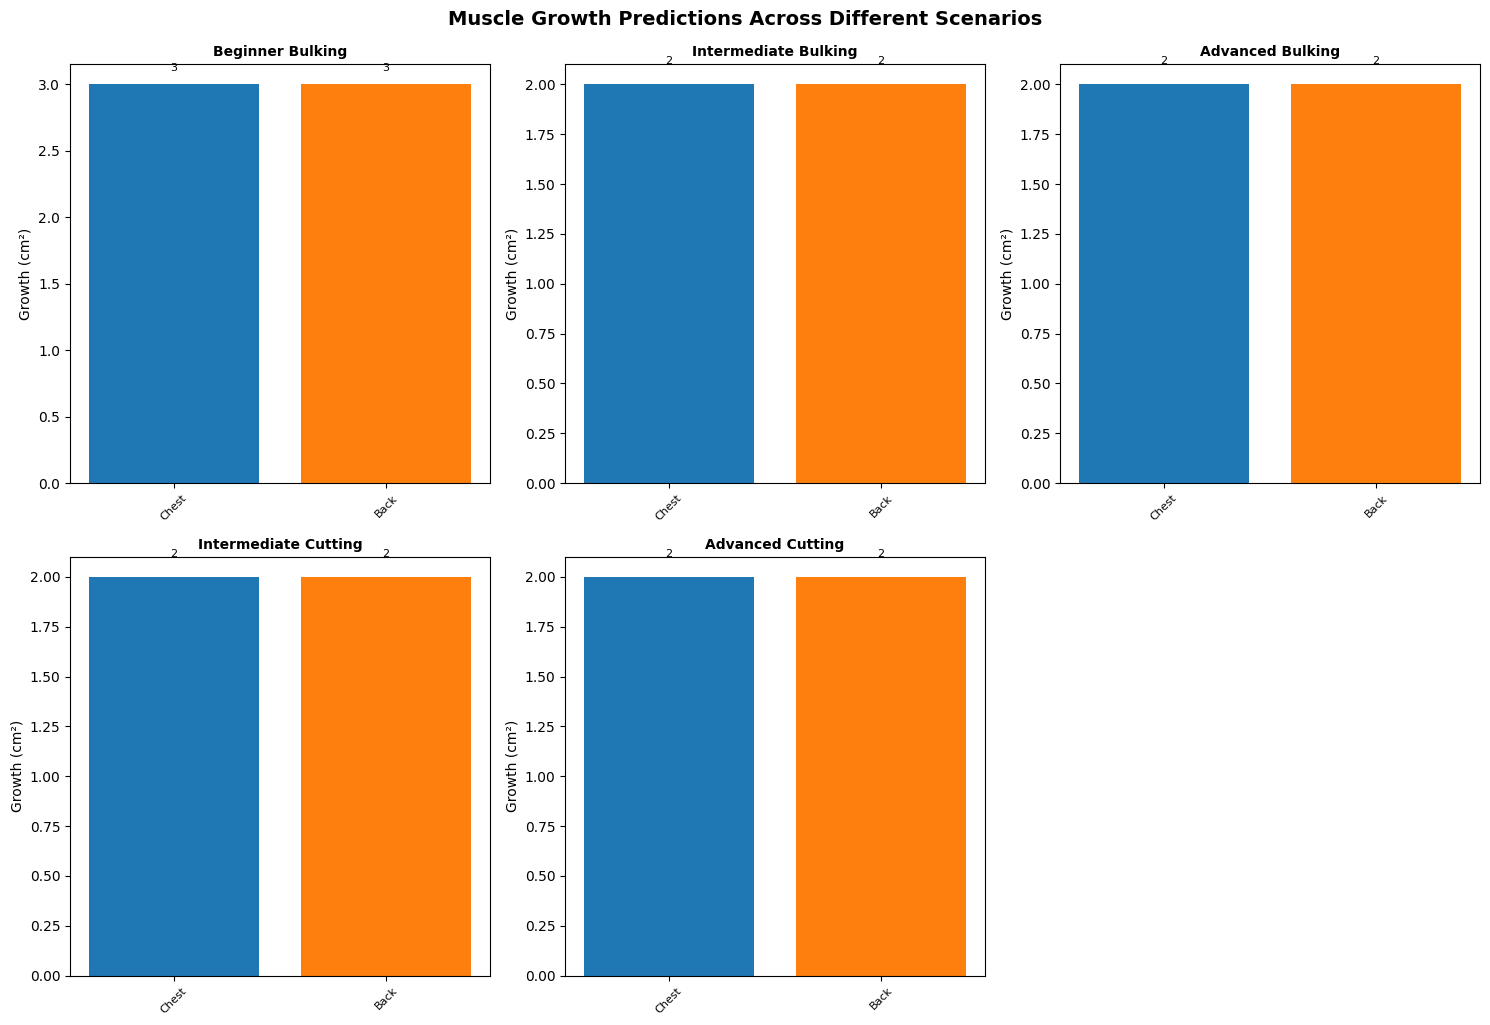


DETAILED PREDICTION RESULTS:

Beginner Bulking:
----------------
Chest growth: 3 cm²

Back growth: 3 cm²

Intermediate Bulking:
--------------------
Chest growth: 2 cm²

Back growth: 2 cm²

Advanced Bulking:
----------------
Chest growth: 2 cm²

Back growth: 2 cm²

Intermediate Cutting:
--------------------
Chest growth: 2 cm²
Definition score: 4

Back growth: 2 cm²
Definition score: 4

Advanced Cutting:
----------------
Chest growth: 2 cm²
Definition score: 4

Back growth: 2 cm²
Definition score: 4


In [64]:
# Visualization of predictions
def visualize_predictions():
    """Create visualizations for the prediction results"""
    
    # Sample data for different scenarios
    scenarios = {
        'Beginner Bulking': {'experience': 'Beginner', 'calories': 3000, 'maintenance': 2500, 'bf': None},
        'Intermediate Bulking': {'experience': 'Intermediate', 'calories': 3000, 'maintenance': 2600, 'bf': None},
        'Advanced Bulking': {'experience': 'Advanced', 'calories': 2900, 'maintenance': 2600, 'bf': None},
        'Intermediate Cutting': {'experience': 'Intermediate', 'calories': 2200, 'maintenance': 2600, 'bf': 15},
        'Advanced Cutting': {'experience': 'Advanced', 'calories': 2100, 'maintenance': 2500, 'bf': 12}
    }
    
    results = {}
    
    for scenario_name, params in scenarios.items():
        result = predict_combined(
            age=28, gender='M', exercises=example_exercises, frequency=4,
            protein=180, calories=params['calories'], sleep=7.5,
            experience=params['experience'],
            maintenance_calories=params['maintenance'],
            body_fat_percentage=params['bf'],
            cardio_minutes_per_week=120 if params['bf'] else 0,
            current_size_cm=30, workout_time_years=2, time_months=3
        )
        results[scenario_name] = result
    
    # Display results
    plt.figure(figsize=(15, 10))
    
    for i, (scenario, result) in enumerate(results.items(), 1):
        plt.subplot(2, 3, i)
        
        # Parse results to extract growth values
        lines = result.split('\n')
        growth_values = []
        muscle_names = []
        
        for line in lines:
            if 'growth:' in line:
                parts = line.split(' growth: ')
                muscle_names.append(parts[0])
                growth_values.append(float(parts[1].split(' cm²')[0]))
        
        if growth_values:
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
            plt.bar(muscle_names, growth_values, color=colors[:len(muscle_names)])
            plt.title(scenario, fontsize=10, fontweight='bold')
            plt.ylabel('Growth (cm²)')
            plt.xticks(rotation=45, fontsize=8)
            
            # Add value labels on bars
            for j, v in enumerate(growth_values):
                plt.text(j, v + 0.1, f'{v:.0f}', ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.suptitle('Muscle Growth Predictions Across Different Scenarios', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.show()
    
    # Print detailed results
    print("\nDETAILED PREDICTION RESULTS:")
    print("=" * 60)
    for scenario, result in results.items():
        print(f"\n{scenario}:")
        print("-" * len(scenario))
        print(result)

# Run visualization
visualize_predictions()